# Pandas Basics

### Use of AI: can be used, but must be reported.
### AI shall not be used to complete the whole assignment.

## Execute every code cell and also take a look at the code and try to understand what is happening.

* Always wait until the cell is run. If you get errors, fix them before going any further.
* Example codes will help you in doing the tasks, understand the examples before going further.
* Do not alter the ready made code.

Topics:
- Recap Pandas basic operations
- Usage of loc and iloc
- Removal of columns and rows
- Filling missing data


In [1]:
# Take libraries in use
import pandas as pd
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns

## Let's use the Titanic dataset today.

## Task 1
* Familiarize yourself with the Titanic dataset: https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv

Then answer these questions (briefly):


1. How many columns there are in the Titanic dataset?
2. Are there missing values?
3. What are the three ports (towns) of emabarkation?



In [2]:
# Load the Titanic data
df = sns.load_dataset('titanic')


Let's find out the usual things from the dataset that are always good the check.

In [3]:
# Checking that the data is read correctly
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Checking general info form the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## Task 2
Which columns contain missing values?

Write your answer here:

In [5]:
# More information (somewhat overlapping with info())
df.shape

(891, 15)

In [6]:
# And descriptive statistics
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## How to select certain rows and cells in DataFrame

Sometimes there is a need to refer to data based on its location or variable name (and/or basic indexing with [] is not enough).
Pandas has following methods to use:
- iloc
- loc

### iloc - Selecting data based on its index

Rows are given numerical values <start>:<end>
- The rows from index <start> to <end> -1 are selected
- For example, 5:7, the values of the 5th and **6th** rows are selected
- If you don't give the start AND end values of the rows, but only : , then all rows
- -1 means the last row

Columns respectively
- For example 2:5, when the columns from **2 to 4** are selected
- If you don't give the start AND end numbers of the columns, but only : , then all columns
- -1 means the last column


##### Examples with rows and columns
- iloc[5:7, 2:5] selects data from rows 5 and 6 and columns 2, 3 and 4
- iloc[ : , 0:1 ] selects data from all rows and the first column
- iloc[ : , -1] selects data from all rows and the the last column


In [7]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [8]:
df.iloc[0:3,0:8]  # rows in indexes 0-2 and columns in index 0-7

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S


## Task 3

In [11]:
# Show all rows for columns 2 - 9 using iloc
df.iloc[:,2:10]


,sex,age,sibsp,parch,fare,embarked,class,who
0,male,22.0,1,0,7.2500,S,Third,man
1,female,38.0,1,0,71.2833,C,First,woman
2,female,26.0,0,0,7.9250,S,Third,woman
3,female,35.0,1,0,53.1000,S,First,woman
4,male,35.0,0,0,8.0500,S,Third,man
...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,S,Second,man
887,female,19.0,0,0,30.0000,S,First,woman
888,female,NaN,1,2,23.4500,S,Third,woman
889,male,26.0,0,0,30.0000,C,First,man


In [13]:
# Show rows 10 - 15 for columns "survived" and "pclass" using iloc
df.loc[10:15,['survived','pclass']]
df.loc[10:15,'survived':'pclass']


# What if the survived and pclass are not next to each other in the dataframe...? What would you do? --> df.loc[10:15,'survived':'pclass']

,survived,pclass
10,1,3
11,1,1
12,0,3
13,0,3
14,0,3
15,1,2


### loc - Selecting data based on the name of the variable in column (in first row)

loc selects the values of columns by specifying the column names for specified rows

- Rows are given numerical values (if them are not renamed to have names)
- Variable names are given as columns.
- Note: if you like select several variables you specify the the first and last

##### Example:

- loc [:, 'fare' ] selects the values of the variable 'fare' from all rows
- loc [0:5, 'class':'deck'] selects the values of the variables from 'class' to 'deck' from rows 0-4

In [14]:
df.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [15]:
df.loc[:15, 'survived':'embark_town']  # first rows 0 - 15 and columns from 'survived' to 'embark_town'

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg


In [16]:
# Names of all columns
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

## Task 4

In [19]:
# Show first 10 rows for last 3 variables in the dataframe using loc
df.loc[:10,'embark_town':'alone']


,embark_town,alive,alone
0,Southampton,no,False
1,Cherbourg,yes,False
2,Southampton,yes,True
3,Southampton,yes,False
4,Southampton,no,True
5,Queenstown,no,True
6,Southampton,no,True
7,Southampton,no,False
8,Southampton,yes,False
9,Cherbourg,yes,False


## How to select certain columns or rows from data - summary
1. Pandas basic indexing (works, but has some limitations):

    df_new = df[['Column1', 'Column2', 'Column3', 'Column4','Column5']]

2. Use **'loc'** - method: 

    df_new = df.loc [:, ['Column1', 'Column2', 'Column3', 'Column4','Column5']]

3. Use **'iloc'** - method:

    df_new = df.iloc [:, n:m] # to select columns from index n to m-1


Columns:

    2 : n -> All positions from index 2 up to index n-1
    -1 -> Last position
    -3 : -1 -> Three last positions

Rows:

    2 : n -> All row positions from index 2 up to index n
    -1 -> Last position
    -3 : -1 -> Three last positions


### Removing data

#### Remove columns with 'drop'

In [20]:
# Let's check the column names again
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [21]:
# Remove certain columns
df.drop(columns = 'alive')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,True


In [22]:
df.drop(columns = ['parch', 'embarked', 'who','alive'])

,survived,pclass,sex,age,sibsp,fare,class,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,7.2500,Third,True,NaN,Southampton,False
1,1,1,female,38.0,1,71.2833,First,False,C,Cherbourg,False
2,1,3,female,26.0,0,7.9250,Third,False,NaN,Southampton,True
3,1,1,female,35.0,1,53.1000,First,False,C,Southampton,False
4,0,3,male,35.0,0,8.0500,Third,True,NaN,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,Second,True,NaN,Southampton,True
887,1,1,female,19.0,0,30.0000,First,False,B,Southampton,True
888,0,3,female,NaN,1,23.4500,Third,False,NaN,Southampton,False
889,1,1,male,26.0,0,30.0000,First,True,C,Cherbourg,True


##### Note: the operation does NOT affect to orginal DataFrame
- DataFrame still contains the variables
- If you like to modify DataFrame, you need to store result in existing DataFrame
- Another option (better) is to store data in new DataFrame

In [23]:
# df still contain same data
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


##### To remove the columns one way is to store the result in other DataFrame


In [24]:
# Result in same DataFrame
df2 = df.drop(columns = ['parch', 'embarked', 'who','alive'])
df2.head()

,survived,pclass,sex,age,sibsp,fare,class,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,7.2500,Third,True,NaN,Southampton,False
1,1,1,female,38.0,1,71.2833,First,False,C,Cherbourg,False
2,1,3,female,26.0,0,7.9250,Third,False,NaN,Southampton,True
3,1,1,female,35.0,1,53.1000,First,False,C,Southampton,False
4,0,3,male,35.0,0,8.0500,Third,True,NaN,Southampton,True


## Task 5

In [27]:
# Remove columns 'adult_male' and 'sibsp', modify the df2 dataframe
df2 = df.drop(columns=['adult_male','sibsp'])

# Then check with df2.head() that you succeeded.
df2.head()



,survived,pclass,sex,age,parch,fare,embarked,class,who,deck,embark_town,alive,alone
0,0,3,male,22.0,0,7.2500,S,Third,man,NaN,Southampton,no,False
1,1,1,female,38.0,0,71.2833,C,First,woman,C,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,NaN,Southampton,yes,True
3,1,1,female,35.0,0,53.1000,S,First,woman,C,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,NaN,Southampton,no,True


##### Missing data can found e.g. using DataFrame methods 'isna' or 'isnull'

In [28]:
df.isna()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [29]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Removing rows with dropna()

- We can drop all rows with 'dropna'
- dropna remove rows with null values

In [30]:
# Result contain only rows where all variables have data
df2 = df.dropna()
df2.info()

<class 'pandas.DataFrame'>
Index: 182 entries, 1 to 889
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     182 non-null    int64   
 1   pclass       182 non-null    int64   
 2   sex          182 non-null    str     
 3   age          182 non-null    float64 
 4   sibsp        182 non-null    int64   
 5   parch        182 non-null    int64   
 6   fare         182 non-null    float64 
 7   embarked     182 non-null    str     
 8   class        182 non-null    category
 9   who          182 non-null    str     
 10  adult_male   182 non-null    bool    
 11  deck         182 non-null    category
 12  embark_town  182 non-null    str     
 13  alive        182 non-null    str     
 14  alone        182 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 18.2 KB


Looks like we lost a lot of rows when dropping all that are missing information.
It is not always a good option to drop all rows with missing data.

### Store other value if missing data
- e.g. mean or median for quantitative data
- or mode for qualitative data
- or use specific value, e.g. 0

These can be done with DataFrame method 'fillna'

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


##### Example: Store mean value as the variable 'age' if value is missing

<Axes: xlabel='age', ylabel='Count'>

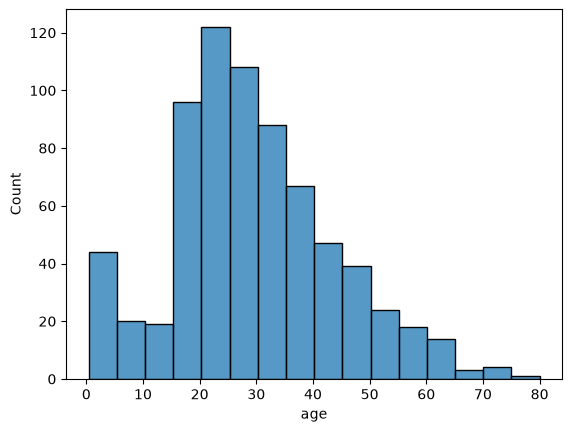

In [32]:
# Check data before the operation
sns.histplot(data = df, x = 'age', binwidth = 5)

In [33]:
agemean = df.age.mean()
agemean

np.float64(29.69911764705882)

In [34]:
# Let's first make a copy of the original dataset, name of the copy is df3
df3 = df

# Then fill the age with mean
df3['age'] = df['age'].fillna(agemean)
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


<Axes: xlabel='age', ylabel='Count'>

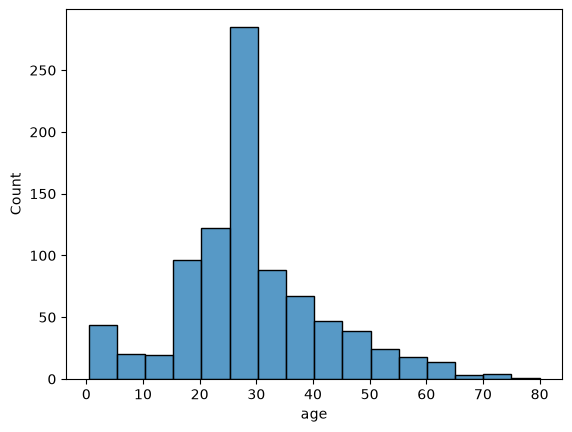

In [35]:
# Check data after the operation
sns.histplot(data = df3, x = 'age', binwidth = 5)

## Task 6: Find how to add mode value using Fillna(). Modify the df3 dataframe.
- First select one categorical variable that has missing values.
- Check how many different values the variable has (hint: unique()) and visualise this (hint: bar chart).
- Then find out the mode and use fillna.
- Check that the changes are made (visualise).

In [ ]:
# Your code here.
# It is good the divide the code into multiple cells, so add code cells if necessary.

### Grouping data with 'groupby'

In [ ]:
df.groupby('class').head(3)

## Task 7
* Did the previous code give some future warning?
* If yes, about what? If not, then move to the question below.
* Which value of observed-parameter of the groupby()-funcion should you use, True or False?

In [ ]:
df3 = df.groupby('pclass').describe()
df3.head()

In [ ]:
df3.head().transpose()

### Addition of new variable (column)

In [ ]:
# Let's make another copy of the original dataframe
df4 = df
df4['fare_age'] = df['fare'] / df['age']
df4.head()

### Conditions

In [ ]:
df5 = df.loc[(df['age'] > 25) & (df['class'] =='First')]
df5

## Task 8
Create a dataframe df6 that contains only survived female passangers who embarked in Cherbourg.

In [ ]:
# Write your code here


# And check, what happened to df6
# Write your code here

### Task 6, AI statement
- Describe here, how did you use AI in this assignment

### Task return
- File > Save and Export Notebook As > HTML
- Then take a look the produced HTML that it looks ok and readable
- Return to Itslearning, only the html document is returned, *not the .ipynb